In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import truncnorm


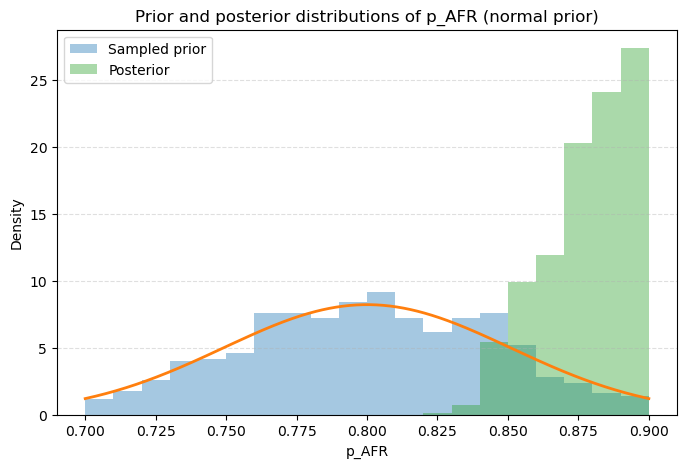

In [29]:
results_df_normal = pd.read_csv("../results/abc_simulation_500_normal.csv")
lower = 0.70
mean = 0.80
upper = 0.90

sd = (upper-lower) / (2 * 1.96)

a = (lower-mean)/sd
b = (upper-mean)/sd

x = np.linspace(lower, upper, 500)

prior_density = truncnorm.pdf(
    x,
    a,
    b,
    loc=mean,
    scale=sd
)

bins = np.linspace(lower, upper, 21)

plt.figure(figsize=(8, 5))

plt.hist(
    results_df_normal["p_AFR"],
    bins=bins,
    density=True,
    alpha=0.4,
    label="Sampled prior"
)

plt.plot(
    x,
    prior_density,
    linewidth=2,
)

plt.hist(
    results_df_normal["p_AFR"],
    bins=bins,
    weights=results_df_normal["posterior"],
    density=True,
    alpha=0.4,
    label="Posterior"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
    zorder=0
)

plt.xlabel("p_AFR")
plt.ylabel("Density")
plt.title("Prior and posterior distributions of p_AFR (normal prior)")
plt.legend()

plt.show()

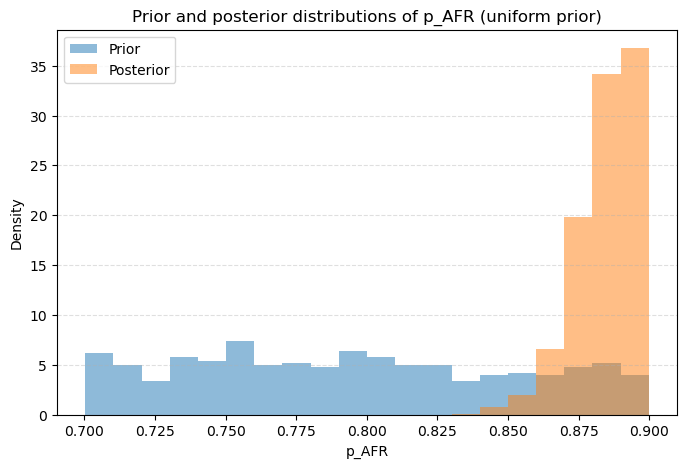

In [28]:
results_df_uniform = pd.read_csv("../results/abc_simulation_500_uniform.csv")

plt.figure(figsize=(8, 5))

plt.hist(
    results_df["p_AFR"],
    bins=20,
    density=True,
    alpha=0.5,
    label="Prior"
)

plt.hist(
    results_df["p_AFR"],
    weights=results_df_uniform["posterior"],
    bins=20,
    density=True,
    alpha=0.5,
    label="Posterior"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
    zorder=0
)

plt.xlabel("p_AFR")
plt.ylabel("Density")
plt.title("Prior and posterior distributions of p_AFR (uniform prior)")
plt.legend()

plt.show()


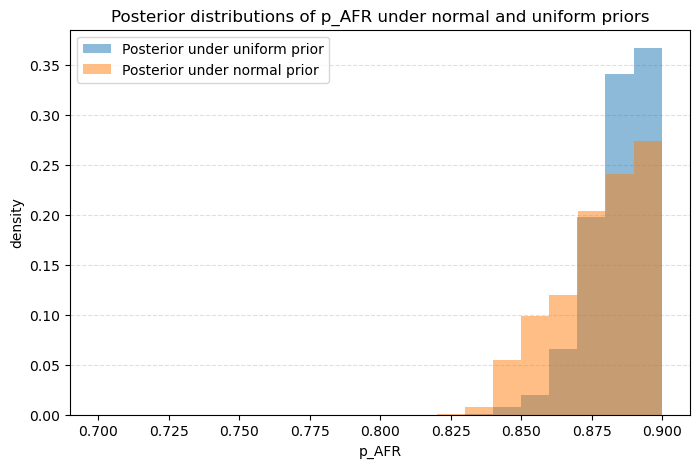

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    results_df_uniform["p_AFR"],
    weights=results_df_uniform["posterior"],
    bins=20,
    alpha=0.5,
    label="Posterior under uniform prior",
    zorder=2
)

plt.hist(
    results_df_normal["p_AFR"],
    bins=bins,
    weights=results_df_normal["posterior"],
    alpha=0.5,
    label="Posterior under normal prior",
    zorder=2
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
    zorder=0
)

plt.xlabel("p_AFR")
plt.ylabel("density")
plt.title("Posterior distributions of p_AFR under normal and uniform priors")
plt.legend()

plt.show()